In [2]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

# Loading Data
#dataset = load_dataset('lukebarousse/data_jobs')
#df = dataset['train'].to_pandas()

df = pd.read_csv("D:\Python_Data_Project\Project\job_postings_up_to_date.csv")

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

df = df[df['job_posted_date'].dt.year == 2025]

d:\Anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


job_title_short
Engineer     96112.500
Scientist    67500.000
Analyst      63599.625
Name: salary_year_avg, dtype: float64


C:\Users\frase\AppData\Local\Temp\ipykernel_6552\2097695970.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df_filtered, x = 'salary_year_avg',y = 'job_title_short', order = job_list, medianprops={'color': 'black','linewidth': 1.2}, boxprops = {'alpha':0.6}, palette = 'Set1')


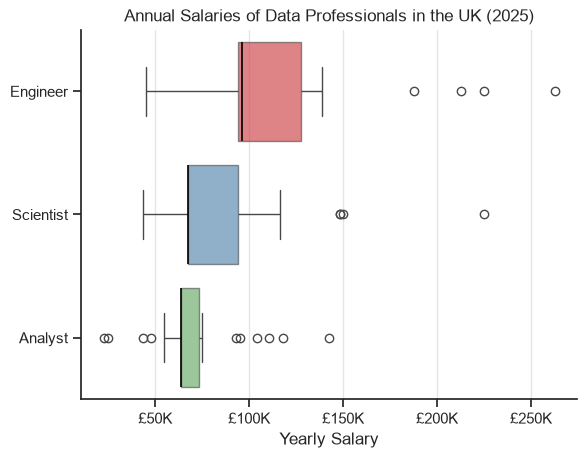

In [63]:
job_titles = ['Data Analyst', 'Data Scientist', 'Data Engineer']
df_filtered = df[(df['job_country'] == 'United Kingdom')
                 & df['job_title_short'].isin(job_titles)]
df_filtered = df_filtered.dropna(subset = ['salary_year_avg']).reset_index()
df_filtered['salary_year_avg'] = df_filtered['salary_year_avg'] * 0.75
label_map = {
    'Data Analyst': 'Analyst',
    'Data Scientist': 'Scientist',
    'Data Engineer': 'Engineer'
}

df_filtered['job_title_short'] = (
    df_filtered['job_title_short'].replace(label_map)
)
df_salaries = (
    df_filtered.groupby('job_title_short')['salary_year_avg'].median()
    .sort_values(ascending = False)
)
job_list = df_salaries.index
print(df_salaries)


sns.set_theme(style = 'ticks')
sns.boxplot(data = df_filtered, x = 'salary_year_avg',y = 'job_title_short', order = job_list, medianprops={'color': 'black','linewidth': 1.2}, boxprops = {'alpha':0.6}, palette = 'Set1')
sns.despine()
plt.title('Annual Salaries of Data Professionals in the UK (2025)')
plt.xlabel('Yearly Salary')
plt.ylabel('')
plt.grid(axis='x', alpha=0.5)
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'£{int(x/1000)}K'))
plt.show()

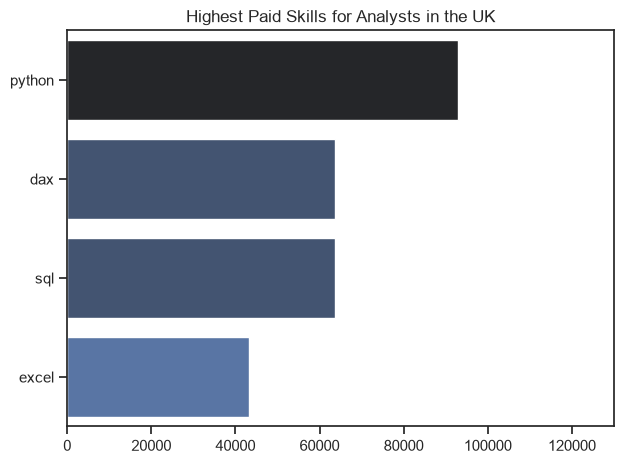

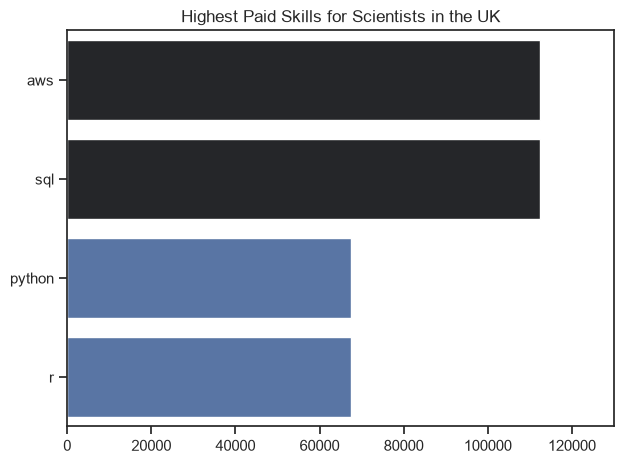

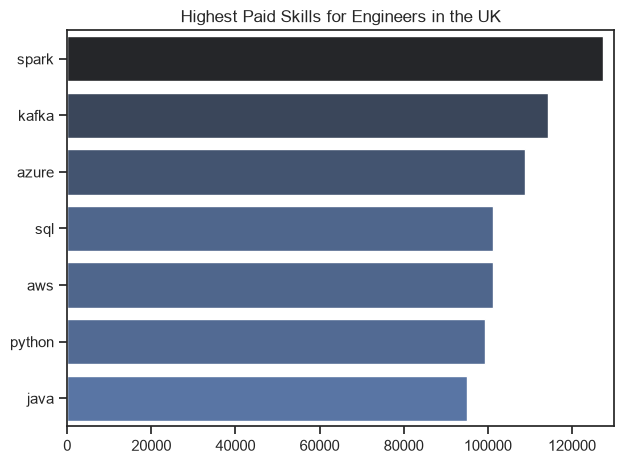

In [62]:
job_list = ['Analyst', 'Scientist', 'Engineer']
df_jobs = [
    df_filtered[
        df_filtered['job_title_short'] == job
    ]
    for job in job_list
]

df_jobs_exploded = [
    i.explode('job_skills').dropna(subset=['job_skills'])
    for i in df_jobs
]
sns.set_theme(style = 'ticks')
for ((i, dframe), job) in zip((enumerate(df_jobs_exploded)), job_list):
    highest_paid_skills = (
        dframe.groupby('job_skills').agg(
        median_salary=('salary_year_avg', 'median'),
        counts = ('salary_year_avg', 'count')
    )
    )
    highest_paid_skills = (
        highest_paid_skills[highest_paid_skills['counts'] >= 5]
        .sort_values(by = 'median_salary', ascending = False)
        .head(7)
    )
    
    sns.barplot(data = highest_paid_skills,
                 x = 'median_salary',
                   y = 'job_skills',
                   hue = 'median_salary',
                   palette = 'dark:b_r'
                )
    plt.title(f"Highest Paid Skills for {job}s in the UK")
    plt.ylabel('')
    plt.xlabel('')
    plt.xlim(0,130000)
    plt.legend().remove()
    plt.tight_layout()
    plt.show()




In [61]:
df_filtered[df_filtered['job_title_short'] == 'Engineer'].reset_index().explode('job_skills').value_counts('job_skills')

job_skills
python           16
sql              12
spark             7
aws               6
kafka             6
azure             5
java              5
scala             4
databricks        4
snowflake         4
kubernetes        4
redshift          3
r                 3
gcp               2
nosql             2
mongodb           2
sql server        2
mysql             2
terraform         2
airflow           2
hadoop            2
pytorch           2
tensorflow        2
scikit-learn      2
postgresql        1
neo4j             1
elasticsearch     1
bigquery          1
docker            1
mongo             1
shell             1
cassandra         1
powershell        1
t-sql             1
c#                1
html              1
css               1
linux             1
ssis              1
ssrs              1
tableau           1
git               1
dynamodb          1
flow              1
slack             1
excel             1
Name: count, dtype: int64